<a href="https://colab.research.google.com/github/Cthiare/Intro-to-Deep-Learning/blob/main/HW2_Recurrent_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECGR 4106/5106 — Intro to Deep Learning
## Homework 2 — Recurrent Models for Next-Character Prediction

## 0. Setup

In [ ]:
import time, math, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print("Device:", device)

FAST_MODE = False

Device: cuda


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(model):
    # float32 params 4 btes each
    return count_params(model) * 4 / 1e6

def perplexity(loss):
    return math.exp(loss)

In [ ]:
class CharModel(nn.Module):
    def __init__(self, vocab_size, hidden_size, rnn_type="LSTM",
                 num_layers=1, fc_hidden=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn = rnn_cls(hidden_size, hidden_size, num_layers=num_layers,
                           batch_first=True)
        if fc_hidden:
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, fc_hidden), nn.ReLU(),
                nn.Linear(fc_hidden, vocab_size))
        else:
            self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        out, _ = self.rnn(self.embedding(x))
        return self.fc(out[:, -1, :])

# Problem 1 (40 pts)

In [ ]:
text_p1 = (
"Next character prediction is a fundamental task in the field of natural language "
"processing (NLP) that involves predicting the next character in a sequence of text "
"based on the characters that precede it. This task is essential for various "
"applications, including text auto-completion, spell checking, and even in the "
"development of sophisticated AI models capable of generating human-like text. "
"At its core, next character prediction relies on statistical models or deep learning "
"algorithms to analyze a given sequence of text and predict which character is most "
"likely to follow. These predictions are based on patterns and relationships learned "
"from large datasets of text during the training phase of the model. "
"One of the most popular approaches to next character prediction involves the use of "
"Recurrent Neural Networks (RNNs), and more specifically, a variant called Long "
"Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential "
"data like text, as they can maintain information in 'memory' about previous characters "
"to inform the prediction of the next character. LSTM networks enhance this capability "
"by being able to remember long-term dependencies, making them even more effective for "
"next character prediction tasks. "
"Training a model for next character prediction involves feeding it large amounts of "
"text data, allowing it to learn the probability of each character's appearance "
"following a sequence of characters. During this training process, the model adjusts "
"its parameters to minimize the difference between its predictions and the actual "
"outcomes, thus improving its predictive accuracy over time. "
"Once trained, the model can be used to predict the next character in a given piece of "
"text by considering the sequence of characters that precede it. This can enhance user "
"experience in text editing software, improve efficiency in coding environments with "
"auto-completion features, and enable more natural interactions with AI-based chatbots "
"and virtual assistants. "
"In summary, next character prediction plays a crucial role in enhancing the "
"capabilities of various NLP applications, making text-based interactions more "
"efficient, accurate, and human-like. Through the use of advanced machine learning "
"models like RNNs and LSTMs, next character prediction continues to evolve, opening "
"new possibilities for the future of text-based technology.")

chars_p1 = sorted(list(set(text_p1)))
stoi_p1 = {c: i for i, c in enumerate(chars_p1)}
itos_p1 = {i: c for i, c in enumerate(chars_p1)}
vocab_p1 = len(chars_p1)
print("Passage length:", len(text_p1), "characters | vocab size:", vocab_p1)

Passage length: 2386 characters | vocab size: 44


In [ ]:
def build_dataset_p1(seq_len):
    X, y = [], []
    for i in range(len(text_p1) - seq_len):
        X.append([stoi_p1[c] for c in text_p1[i:i+seq_len]])
        y.append(stoi_p1[text_p1[i+seq_len]])
    X, y = np.array(X), np.array(y)
    Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, random_state=42)
    to = lambda a: torch.tensor(a, dtype=torch.long).to(device)
    return to(Xtr), to(ytr), to(Xv), to(yv)

def train_p1(rnn_type, seq_len, hidden_size=128, epochs=200, lr=5e-3):
    Xtr, ytr, Xv, yv = build_dataset_p1(seq_len)
    model = CharModel(vocab_p1, hidden_size, rnn_type).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    losses = []
    t0 = time.time()
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = crit(model(Xtr), ytr); loss.backward(); opt.step()
        losses.append(loss.item())
    train_time = time.time() - t0
    model.eval()
    with torch.no_grad():
        out = model(Xv)
        val_loss = crit(out, yv).item()
        val_acc = (out.argmax(1) == yv).float().mean().item()
    return {
        "model": rnn_type, "seq_len": seq_len,
        "train_loss": round(losses[-1], 4),
        "val_acc": round(val_acc, 4),
        "perplexity": round(perplexity(val_loss), 3),
        "params": count_params(model),
        "size_MB": round(model_size_mb(model), 3),
        "train_time_s": round(train_time, 2),
    }, losses

In [ ]:
P1_EPOCHS = 60 if FAST_MODE else 300
results_p1, curves_p1 = [], {}
for rnn_type in ["RNN", "LSTM", "GRU"]:
    for seq_len in [10, 20, 30]:
        res, losses = train_p1(rnn_type, seq_len, epochs=P1_EPOCHS)
        results_p1.append(res)
        curves_p1[(rnn_type, seq_len)] = losses
        print(res)

df_p1 = pd.DataFrame(results_p1)
df_p1

{'model': 'RNN', 'seq_len': 10, 'train_loss': 0.0387, 'val_acc': 0.4706, 'perplexity': 28.152, 'params': 44332, 'size_MB': 0.177, 'train_time_s': 1.72}
{'model': 'RNN', 'seq_len': 20, 'train_loss': 0.0102, 'val_acc': 0.4705, 'perplexity': 25.074, 'params': 44332, 'size_MB': 0.177, 'train_time_s': 2.07}
{'model': 'RNN', 'seq_len': 30, 'train_loss': 0.0082, 'val_acc': 0.5085, 'perplexity': 34.189, 'params': 44332, 'size_MB': 0.177, 'train_time_s': 2.55}
{'model': 'LSTM', 'seq_len': 10, 'train_loss': 0.039, 'val_acc': 0.4727, 'perplexity': 17.223, 'params': 143404, 'size_MB': 0.574, 'train_time_s': 4.22}
{'model': 'LSTM', 'seq_len': 20, 'train_loss': 0.011, 'val_acc': 0.4747, 'perplexity': 19.088, 'params': 143404, 'size_MB': 0.574, 'train_time_s': 6.06}
{'model': 'LSTM', 'seq_len': 30, 'train_loss': 0.0061, 'val_acc': 0.464, 'perplexity': 19.991, 'params': 143404, 'size_MB': 0.574, 'train_time_s': 8.69}
{'model': 'GRU', 'seq_len': 10, 'train_loss': 0.0378, 'val_acc': 0.5273, 'perplexity'

,model,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s
0,RNN,10,0.0387,0.4706,28.152,44332,0.177,1.72
1,RNN,20,0.0102,0.4705,25.074,44332,0.177,2.07
2,RNN,30,0.0082,0.5085,34.189,44332,0.177,2.55
3,LSTM,10,0.0390,0.4727,17.223,143404,0.574,4.22
4,LSTM,20,0.0110,0.4747,19.088,143404,0.574,6.06
5,LSTM,30,0.0061,0.4640,19.991,143404,0.574,8.69
6,GRU,10,0.0378,0.5273,18.094,110380,0.442,2.84
7,GRU,20,0.0095,0.5295,16.887,110380,0.442,4.32
8,GRU,30,0.0044,0.5212,22.539,110380,0.442,6.07


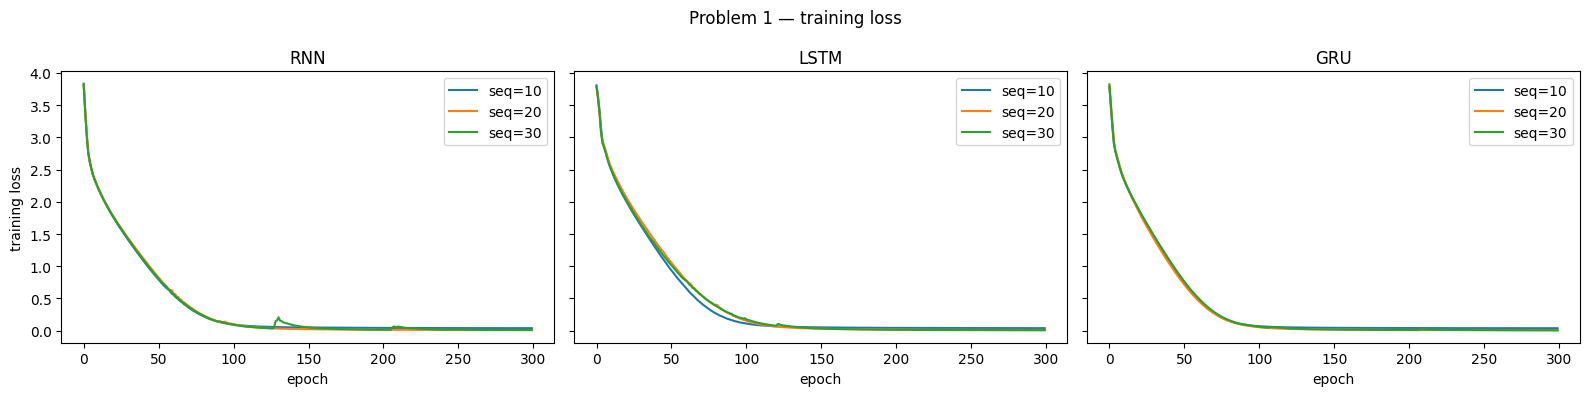

In [ ]:
# Training-loss curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, rnn_type in zip(axes, ["RNN", "LSTM", "GRU"]):
    for seq_len in [10, 20, 30]:
        ax.plot(curves_p1[(rnn_type, seq_len)], label=f"seq={seq_len}")
    ax.set_title(rnn_type); ax.set_xlabel("epoch"); ax.legend()
axes[0].set_ylabel("training loss")
plt.suptitle("Problem 1 — training loss"); plt.tight_layout(); plt.show()

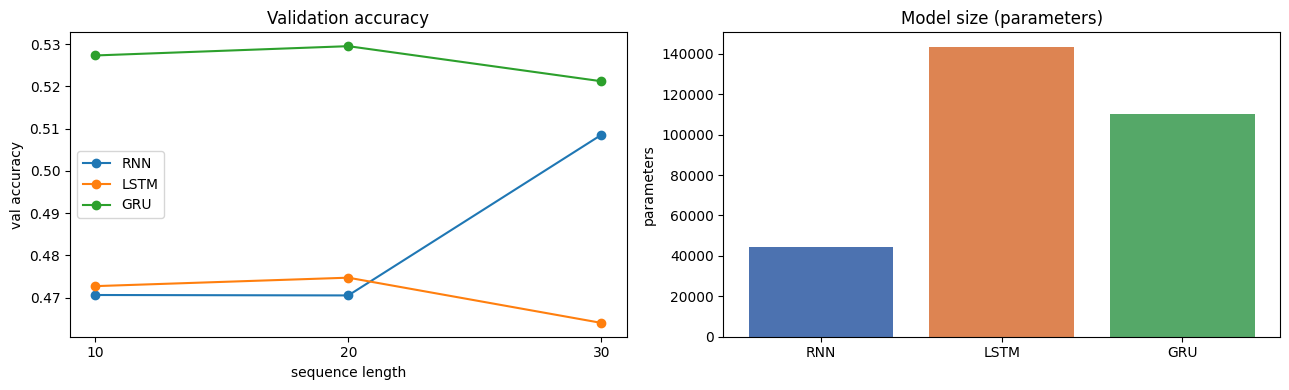

In [ ]:
# Validation accuracy and parameter count
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for rnn_type in ["RNN", "LSTM", "GRU"]:
    sub = df_p1[df_p1.model == rnn_type]
    ax[0].plot(sub.seq_len, sub.val_acc, marker="o", label=rnn_type)
ax[0].set_xlabel("sequence length"); ax[0].set_ylabel("val accuracy")
ax[0].set_title("Validation accuracy"); ax[0].set_xticks([10,20,30]); ax[0].legend()

order = ["RNN", "LSTM", "GRU"]
ax[1].bar(order, [df_p1[df_p1.model==m].params.iloc[0] for m in order],
          color=["#4c72b0","#dd8452","#55a868"])
ax[1].set_ylabel("parameters"); ax[1].set_title("Model size (parameters)")
plt.tight_layout(); plt.show()

# Problem 2 (60 pts)

Build `LSTM` and `GRU` models for the **tiny Shakespeare** dataset using the
provided loader style (`shakespeare-loader.py`).


In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    import requests
    full_text = requests.get(url).text
except Exception:
    full_text = urllib.request.urlopen(url).read().decode("utf-8")
text_p2 = full_text[:150_000] if FAST_MODE else full_text
chars_p2 = sorted(list(set(text_p2)))
stoi_p2 = {c: i for i, c in enumerate(chars_p2)}
itos_p2 = {i: c for i, c in enumerate(chars_p2)}
vocab_p2 = len(chars_p2)
encoded_p2 = [stoi_p2[c] for c in text_p2]
print("Using", len(text_p2), "characters | vocab size:", vocab_p2)

Using 1115394 characters | vocab size: 65


In [ ]:
class CharDataset(Dataset):
    def __init__(self, encoded, seq_len):
        seqs, tgts = [], []
        for i in range(len(encoded) - seq_len):
            seqs.append(encoded[i:i+seq_len]); tgts.append(encoded[i+seq_len])
        self.sequences = torch.tensor(seqs, dtype=torch.long)
        self.targets = torch.tensor(tgts, dtype=torch.long)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, i): return self.sequences[i], self.targets[i]

def make_loaders(seq_len, batch_size=256):
    ds = CharDataset(encoded_p2, seq_len)
    n_tr = int(len(ds) * 0.8)
    tr, te = random_split(ds, [n_tr, len(ds) - n_tr],
                          generator=torch.Generator().manual_seed(42))
    return (DataLoader(tr, batch_size=batch_size, shuffle=True),
            DataLoader(te, batch_size=batch_size, shuffle=False))

In [ ]:
@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval(); tot = correct = 0; loss_sum = nb = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss_sum += crit(out, yb).item(); nb += 1
        correct += (out.argmax(1) == yb).sum().item(); tot += yb.size(0)
    return loss_sum / nb, correct / tot

def train_p2(rnn_type, seq_len, hidden_size=256, num_layers=1, fc_hidden=None,
             epochs=5, lr=2e-3, batch_size=256, label=None):
    train_loader, test_loader = make_loaders(seq_len, batch_size)
    model = CharModel(vocab_p2, hidden_size, rnn_type, num_layers, fc_hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
    train_time = time.time() - t0

    # inference time
    model.eval(); t1 = time.time()
    with torch.no_grad():
        for xb, _ in test_loader:
            model(xb.to(device))
    infer_time = (time.time() - t1) / max(len(test_loader), 1) * 1000

    val_loss, val_acc = evaluate(model, test_loader, crit)
    return model, {
        "label": label or rnn_type,
        "model": rnn_type, "seq_len": seq_len,
        "hidden": hidden_size, "layers": num_layers, "fc_hidden": fc_hidden,
        "train_loss": round(loss.item(), 4),
        "val_acc": round(val_acc, 4),
        "perplexity": round(perplexity(val_loss), 3),
        "params": count_params(model),
        "size_MB": round(model_size_mb(model), 3),
        "train_time_s": round(train_time, 2),
        "infer_ms_per_batch": round(infer_time, 3),
    }

In [ ]:
@torch.no_grad()
def generate(model, seed, length=200, seq_len=30):
    model.eval()
    s = seed
    for _ in range(length):
        ctx = [stoi_p2.get(c, 0) for c in s[-seq_len:]]
        x = torch.tensor([ctx], dtype=torch.long).to(device)
        nxt = model(x).argmax(1).item()
        s += itos_p2[nxt]
    return s

## Problem 2.1 — LSTM vs GRU at sequence lengths 20 and 30

In [ ]:
P2_EPOCHS = 3 if FAST_MODE else 10
results_p21 = []
for rnn_type in ["LSTM", "GRU"]:
    for seq_len in [20, 30]:
        _, res = train_p2(rnn_type, seq_len, hidden_size=256,
                          epochs=P2_EPOCHS)
        results_p21.append(res); print(res)

df_p21 = pd.DataFrame(results_p21)[
    ["model","seq_len","train_loss","val_acc","perplexity",
     "params","size_MB","train_time_s","infer_ms_per_batch"]]
df_p21

{'label': 'LSTM', 'model': 'LSTM', 'seq_len': 20, 'hidden': 256, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.3665, 'val_acc': 0.5768, 'perplexity': 3.986, 'params': 559681, 'size_MB': 2.239, 'train_time_s': 240.39, 'infer_ms_per_batch': 2.51}
{'label': 'LSTM', 'model': 'LSTM', 'seq_len': 30, 'hidden': 256, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.3279, 'val_acc': 0.5789, 'perplexity': 3.957, 'params': 559681, 'size_MB': 2.239, 'train_time_s': 357.14, 'infer_ms_per_batch': 3.258}
{'label': 'GRU', 'model': 'GRU', 'seq_len': 20, 'hidden': 256, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.3892, 'val_acc': 0.5491, 'perplexity': 4.431, 'params': 428097, 'size_MB': 1.712, 'train_time_s': 200.89, 'infer_ms_per_batch': 2.148}
{'label': 'GRU', 'model': 'GRU', 'seq_len': 30, 'hidden': 256, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.4251, 'val_acc': 0.5555, 'perplexity': 4.342, 'params': 428097, 'size_MB': 1.712, 'train_time_s': 283.04, 'infer_ms_per_batch': 2.757}


,model,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s,infer_ms_per_batch
0,LSTM,20,1.3665,0.5768,3.986,559681,2.239,240.39,2.510
1,LSTM,30,1.3279,0.5789,3.957,559681,2.239,357.14,3.258
2,GRU,20,1.3892,0.5491,4.431,428097,1.712,200.89,2.148
3,GRU,30,1.4251,0.5555,4.342,428097,1.712,283.04,2.757


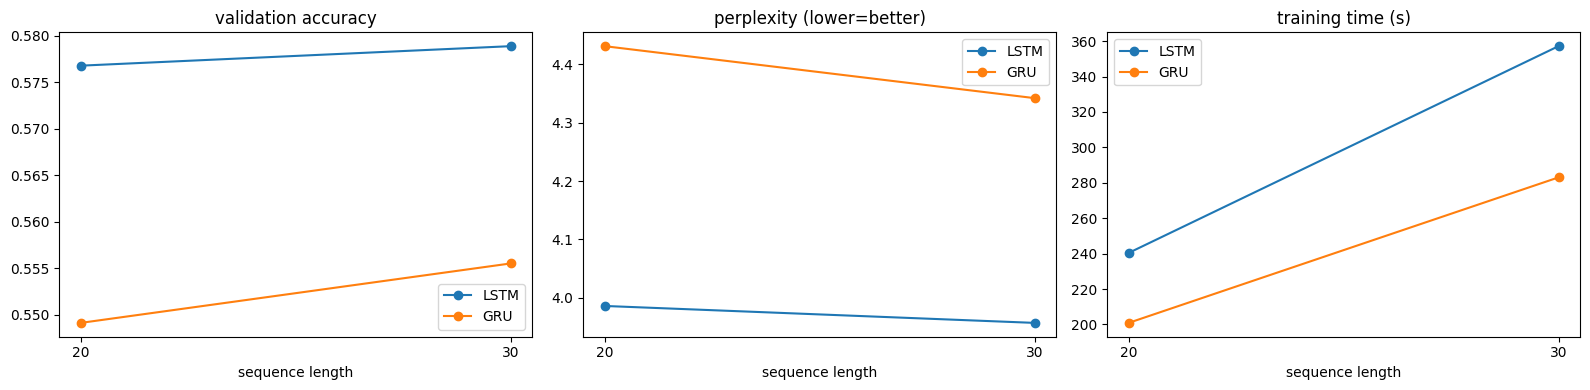

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
metrics = [("val_acc","validation accuracy"),
           ("perplexity","perplexity (lower=better)"),
           ("train_time_s","training time (s)")]
for a,(col,title) in zip(ax, metrics):
    for m in ["LSTM","GRU"]:
        sub = df_p21[df_p21.model==m]
        a.plot(sub.seq_len, sub[col], marker="o", label=m)
    a.set_xlabel("sequence length"); a.set_title(title)
    a.set_xticks([20,30]); a.legend()
plt.tight_layout(); plt.show()

### Problem 2.1 — discussion

*(Fill in with your final numbers.)* LSTM and GRU reach similar validation
accuracy / perplexity on tiny Shakespeare. **GRU** has fewer parameters
(3 gates vs LSTM's 4) so it trains faster and is lighter, while **LSTM**
sometimes generalizes slightly better thanks to its separate cell state.
Moving from sequence length 20 → 30 gives the model more context, which
typically lowers perplexity a little at the cost of more compute per step
(longer unroll → longer training time).

## Problem 2.2 — Hyperparameter study

In [ ]:

sweep = [
    dict(label="baseline (h=256,L=1)",       hidden_size=256, num_layers=1, fc_hidden=None),
    dict(label="smaller hidden (h=128)",     hidden_size=128, num_layers=1, fc_hidden=None),
    dict(label="larger hidden (h=512)",      hidden_size=512, num_layers=1, fc_hidden=None),
    dict(label="2 recurrent layers",         hidden_size=256, num_layers=2, fc_hidden=None),
    dict(label="extra FC head (fc=256)",     hidden_size=256, num_layers=1, fc_hidden=256),
]
P22_EPOCHS = 3 if FAST_MODE else 8

results_p22, models_p22 = [], {}
for cfg in sweep:
    model, res = train_p2("LSTM", seq_len=30, epochs=P22_EPOCHS, **cfg)
    results_p22.append(res); models_p22[cfg["label"]] = model
    print(res)

df_p22 = pd.DataFrame(results_p22)[
    ["label","hidden","layers","fc_hidden","val_acc","perplexity",
     "params","size_MB","train_time_s","infer_ms_per_batch"]]
df_p22

{'label': 'baseline (h=256,L=1)', 'model': 'LSTM', 'seq_len': 30, 'hidden': 256, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.6355, 'val_acc': 0.5788, 'perplexity': 3.964, 'params': 559681, 'size_MB': 2.239, 'train_time_s': 285.59, 'infer_ms_per_batch': 3.128}
{'label': 'smaller hidden (h=128)', 'model': 'LSTM', 'seq_len': 30, 'hidden': 128, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.3016, 'val_acc': 0.565, 'perplexity': 4.205, 'params': 148801, 'size_MB': 0.595, 'train_time_s': 134.5, 'infer_ms_per_batch': 1.959}
{'label': 'larger hidden (h=512)', 'model': 'LSTM', 'seq_len': 30, 'hidden': 512, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.4497, 'val_acc': 0.5786, 'perplexity': 3.954, 'params': 2167873, 'size_MB': 8.671, 'train_time_s': 941.29, 'infer_ms_per_batch': 11.478}
{'label': '2 recurrent layers', 'model': 'LSTM', 'seq_len': 30, 'hidden': 256, 'layers': 2, 'fc_hidden': None, 'train_loss': 1.328, 'val_acc': 0.5869, 'perplexity': 3.834, 'params': 1086017, 'size_MB': 4.3

,label,hidden,layers,fc_hidden,val_acc,perplexity,params,size_MB,train_time_s,infer_ms_per_batch
0,"baseline (h=256,L=1)",256,1,NaN,0.5788,3.964,559681,2.239,285.59,3.128
1,smaller hidden (h=128),128,1,NaN,0.5650,4.205,148801,0.595,134.50,1.959
2,larger hidden (h=512),512,1,NaN,0.5786,3.954,2167873,8.671,941.29,11.478
3,2 recurrent layers,256,2,NaN,0.5869,3.834,1086017,4.344,567.48,6.641
4,extra FC head (fc=256),256,1,256.0,0.5808,3.907,625473,2.502,286.79,3.568


In [ ]:
seed = "ROMEO: "
for label, model in models_p22.items():
    print(f"\n--- {label} ---")
    print(generate(model, seed, length=160, seq_len=30))


--- baseline (h=256,L=1) ---
ROMEO: I will not so.

CORIOLANUS:
What shall be so long and my lord,
Which to bear the world to the world to the world to the world to the world to the world to the w

--- smaller hidden (h=128) ---
ROMEO: I am the seashing the seashing than the seashing the seashing than the seashing the seashing than the seashing the seashing than the seashing the seashing than 

--- larger hidden (h=512) ---
ROMEO: I have speak to the sea as the state of the senate,
The state of the senate of the senate,
The state of the senate of the senate,
The state of the senate of the

--- 2 recurrent layers ---
ROMEO: I have not the world be so shall be so strange to the country.

KING RICHARD II:
What shall I do not stay to the country.

KING RICHARD II:
What shall I do not 

--- extra FC head (fc=256) ---
ROMEO: I will not be the sentence to the world,
That thou art the senate to the world,
That thou art the senate to the world,
That thou art the senate to the world,
Th


## Problem 2.3 — Sequence length 50

In [ ]:
results_p23 = []
for rnn_type in ["LSTM", "GRU"]:
    _, res = train_p2(rnn_type, seq_len=50, hidden_size=256,
                      epochs=P2_EPOCHS)
    results_p23.append(res); print(res)

df_p23 = pd.DataFrame(results_p23)[
    ["model","seq_len","train_loss","val_acc","perplexity",
     "params","size_MB","train_time_s","infer_ms_per_batch"]]
df_p23

{'label': 'LSTM', 'model': 'LSTM', 'seq_len': 50, 'hidden': 256, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.3435, 'val_acc': 0.5784, 'perplexity': 3.937, 'params': 559681, 'size_MB': 2.239, 'train_time_s': 551.39, 'infer_ms_per_batch': 5.177}
{'label': 'GRU', 'model': 'GRU', 'seq_len': 50, 'hidden': 256, 'layers': 1, 'fc_hidden': None, 'train_loss': 1.7893, 'val_acc': 0.5524, 'perplexity': 4.389, 'params': 428097, 'size_MB': 1.712, 'train_time_s': 458.59, 'infer_ms_per_batch': 4.312}


,model,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s,infer_ms_per_batch
0,LSTM,50,1.3435,0.5784,3.937,559681,2.239,551.39,5.177
1,GRU,50,1.7893,0.5524,4.389,428097,1.712,458.59,4.312
